## Introduction

This project analyzes customer reordering behavior using the Instacart dataset. We examine how frequently items are reordered and whether this behavior varies across different conditions.

Specifically, we estimate the overall reorder rate, test whether reorder behavior differs between weekends and weekdays, and model how the number of reordered items depends on cart size and time-related variables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Preparation

We combine order-level and product-level data to construct variables needed for analysis. Due to the large size of the dataset, we use a random sample to ensure the code runs efficiently while preserving the overall distribution.

In [27]:
# load data
orders = pd.read_csv(
    'orders.csv', usecols=['order_id', 'order_dow', 'order_hour_of_day'])

order_products = pd.read_csv(
    'order_products__prior.csv', usecols=['order_id', 'product_id', 'reordered'])

# sample to avoid crashing
order_products = order_products.sample(n=200000, random_state=42)

products = pd.read_csv(
    'products.csv', usecols=['product_id', 'product_name', 'department_id'])

departments = pd.read_csv('departments.csv')


In [28]:
# merge
df = order_products.merge(orders, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(departments, on='department_id')

In [29]:
# cart size (items per order)
cart_size = df.groupby('order_id').size()
cart_size = cart_size.reset_index()
cart_size.columns = ['order_id', 'cart_size']

df = df.merge(cart_size, on='order_id')

# reordered count per order
reordered_count = df.groupby('order_id')['reordered'].sum()
reordered_count = reordered_count.reset_index()
reordered_count.columns = ['order_id', 'reordered_count']
df = df.merge(reordered_count, on='order_id')

# reorder rate per order
df['reorder_rate'] = df['reordered'] / df['cart_size']

# weekend indicator
df['is_weekend'] = 0
df.loc[df['order_dow'] == 0, 'is_weekend'] = 1
df.loc[df['order_dow'] == 6, 'is_weekend'] = 1

In [30]:
df.to_csv('clean_instacart.csv', index=False)

## Visualizations

# Here we made a line graph showing average reorder rate for different cart sizes.

In [ ]:
r_by_size = order_level.groupby('cart_size')['reorder_rate'].mean().reset_index().sort_values('cart_size')
max_size = 20
r_by_size_plot = r_by_size[r_by_size['cart_size'] <= max_size]

plt.figure()
plt.plot(r_by_size_plot['cart_size'], r_by_size_plot['reorder_rate'], marker='o', color='blue', label='Avg reorder rate')
plt.title('How does average reorder rate change with cart size?')
plt.xlabel('Cart size (items per order)')
plt.ylabel('Fraction of items in order that were reordered)')
plt.xticks(r_by_size_plot['cart_size'])
plt.ylim(0,1)
plt.grid(True)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

This visualization shows that as the cart size increases the reorder rate increases. This shows that larger cart sizes results in what is likely more standard orders that is shown by these larger cart orders being repeated more frequently. 

# Here we made a histogram showing the frequency of different cart sizes.

In [ ]:
plt.figure()
hist_max = 40
cart_vals = order_level['cart_size'].clip(upper=hist_max)
bins = np.arange(1, hist_max+2) - 0.5
plt.hist(cart_vals, bins=bins, edgecolor='black', color='pink')
plt.title('Distribution of cart sizes across orders of cart sizes')
plt.xlabel(f'Cart size (items per order). Values >= {hist_max} are clipped for display')
plt.ylabel('Number of orders ')
plt.xticks(range(1, hist_max+1, 2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This histogram is relatively evenly distributed showing that there is not a strong preference for people in ordering very small or very large carts.

Here we made a bar chart showing the average reorder rate by department. 

In [ ]:
dept_stats = df.groupby('department')['reordered'].mean().rename('avg_reorder_rate').reset_index()
dept_counts = df.groupby('department').size().rename('n_items').reset_index()
dept_stats = dept_stats.merge(dept_counts, on='department').sort_values('avg_reorder_rate', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(dept_stats['department'], dept_stats['avg_reorder_rate'], color='purple', alpha=0.9)
plt.gca().invert_yaxis()
plt.title('Which departments have highest average item-level reorder rates?')
plt.xlabel('Fraction of items in that department reordered')
plt.ylabel('Department name')
plt.xlim(0,1)

for i, (rate, n) in enumerate(zip(dept_stats['avg_reorder_rate'], dept_stats['n_items'])):
plt.text(rate + 0.01, i, f'n={n}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

This shows that the most frequently reordered department is frozen goods. This is likley due to the fact that frozen goods are traditionally household staple items.

# Here we made a bar chart showing reorder counts for the top products.

In [ ]:
prod_reorders = df.groupby(['product_id','product_name'])['reordered'].sum().rename('reorder_count').reset_index()
top10 = prod_reorders.sort_values('reorder_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
y = top10['product_name'][::-1]
x = top10['reorder_count'][::-1]
plt.barh(y, x, color='green')
plt.title('Top 10 most frequently reordered products')
plt.xlabel('Number of times product was reordered)')
plt.ylabel('Product name')

for xi, yi in zip(x, y):
plt.text(xi + max(x)*0.01, yi, f'{int(xi)}', va='center')
plt.tight_layout()
plt.show()

This graph shows that pantry had the largest reorder counts showing that despite not having the highest ratio its large number of orders likely skewed the data resulting in it having the most reordered total goods.

Here we made a line graph showing total orders by hour.

In [ ]:
orders_by_hour = order_level.groupby('order_hour_of_day').size().rename('n_orders').reset_index().sort_values('order_hour_of_day')

plt.figure()
plt.plot(orders_by_hour['order_hour_of_day'], orders_by_hour['n_orders'], marker='o', linestyle='-', color='orange', label='Total orders')
plt.title('How many orders occur at each hour of day?')
plt.xlabel('Hour of day (0-23)')
plt.ylabel('Number of orders')
plt.xticks(range(0,24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This shows that the total orders by hour is centered within the businesses operational hours and is much more centered midday.

Here we made a line graph showing reorder rate by hour.

In [ ]:
hour_reorder = order_level.groupby('order_hour_of_day')['reorder_rate'].mean().reset_index().sort_values('order_hour_of_day')

plt.figure()
plt.plot(hour_reorder['order_hour_of_day'], hour_reorder['reorder_rate'], marker='o', linestyle='-', color='crimson', label='Avg reorder rate')
plt.title('Do reorder rates differ by hour of day?')
plt.xlabel('Hour of day (0-23)')
plt.ylabel('Fraction of items in order that were reordered)')
plt.xticks(range(0,24))
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

This visualization shows that the reorder rate is uch higher in the mornings likely symbolizing that regular shoppers shop more in the morning and there are more impulse buyers in the afternoons into evenings.

## Confidence Interval

We estimate a 95% confidence interval for the reorder rate using bootstrap resampling.

In [37]:
# reorder values
reorder_values = df['reordered']

boot_means = []

# bootstrap
for i in range(2000):
    sample = reorder_values.sample(frac=1, replace=True)
    boot_means.append(sample.mean())

# confidence interval
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print("CI:", ci_lower, ci_upper)

CI: 0.5878948749999999 0.5923003750000001


The 95% confidence interval is approximately (0.588, 0.592). This indicates that the true reorder rate is tightly concentrated within this range. The narrow interval suggests a precise estimate due to the large sample size.

## Hypothesis Test

H₀: The reorder rate is the same on weekends and weekdays  
Hₐ: The reorder rate differs between weekends and weekdays  

In [42]:
# split groups
weekend = df[df['is_weekend'] == 1]['reordered']
weekday = df[df['is_weekend'] == 0]['reordered']

# sample sizes
n1 = len(weekend)
n2 = len(weekday)

# proportions
p1 = weekend.mean()
p2 = weekday.mean()

# pooled proportion
p_pool = (weekend.sum() + weekday.sum()) / (n1 + n2)

# standard error
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

# z-statistic
z = (p1 - p2) / se

# p-value (two-sided)
from scipy.stats import norm
p_value = 2 * (1 - norm.cdf(abs(z)))

print("z-statistic:", z)
print("p-value:", p_value)

z-statistic: -4.958964333871255
p-value: 7.08699755103126e-07


The p-value is extremely small (approximately 7.09 × 10⁻⁷), which is well below 0.05. Therefore, we reject the null hypothesis. There is strong evidence that reorder behavior differs between weekends and weekdays, with slightly lower reorder rates on weekends.

## Regression

We model reordered item counts as a function of cart size and time-related variables.

In [39]:
from sklearn.linear_model import LinearRegression

# define variables
X = df[['cart_size', 'order_hour_of_day', 'order_dow']]
y = df['reordered_count']

# fit model
model = LinearRegression()
model.fit(X, y)

# results
print("Coefficients:", model.coef_)
print("Intercept:", model.score(X, y))
print("R^2:", model.score(X,y))

Coefficients: [ 0.59259859 -0.00228273 -0.00129005]
Intercept: 0.10651528312359015
R^2: 0.10651528312359015


Cart size has a strong positive relationship with reordered item counts, indicating that larger orders tend to include more reordered items. The effects of order hour and day of the week are minimal, as their coefficients are close to zero.

The R² value of approximately 0.106 indicates that the model explains about 10.6% of the variation, suggesting that other factors also influence reordering behavior.

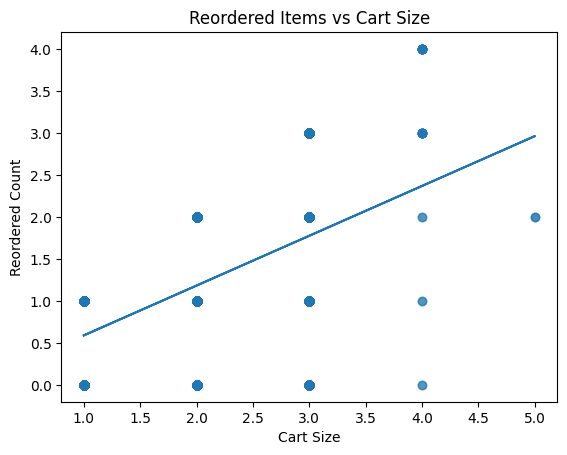

In [40]:
plt.scatter(df['cart_size'], df['reordered_count'], alpha=0.3)

# line of best fit
z = np.polyfit(df['cart_size'], df['reordered_count'], 1)
p = np.poly1d(z)

plt.plot(df['cart_size'], p(df['cart_size']))

plt.xlabel("Cart Size")
plt.ylabel("Reordered Count")
plt.title("Reordered Items vs Cart Size")

plt.show()

The plot shows a positive relationship between cart size and reordered items. As cart size increases, reordered counts tend to increase, though there is still variability not captured by the model.

## Conclusion

The reorder rate is estimated with high precision and lies within a narrow range. The hypothesis test shows strong evidence that reorder behavior differs between weekends and weekdays.

Regression results indicate that cart size is the primary factor influencing reorder counts, while time-related variables have little impact. Overall, purchase size appears to be a stronger driver of reordering behavior than timing.

## AI Usage

I used AI briefly to help fix some issues when loading the dataset. The rest of the code, analysis, and explanations were done on my own.